# MATH50003 (2025–26)
# Lab 7: IV.1 Polynomial Interpolation and Regression and IV.2 SVD and Compression

We  explore polynomial interpolation and regression, and see that when
interpolating at an evenly spaced grid one can encounter issues with convergence.
This is overcome via regression, but we are left with the question of how to
solve the underlying least squares problems.

**Learning Outcomes**

Mathematical knowledge:

1. Vandermonde matrices and least squares.
2. Constructing interpolatory quadrature rules.
3. Issues with interpolation at evenly spaced points with functions with small radii of convergence.
4.

We first load  packages we need including a couple new ones:

In [23]:
# LinearAlgebra contains routines for doing linear algebra
using LinearAlgebra, Plots, Test

## IV.1 Polynomial Interpolation and Regression

We now explore the practical usage of polynomial interpolation and regression.
In particular we will see that polynomial interpolation may fail as the number
of points becomes large.

### IV.1.1 Polynomial Interpolation

A quick-and-dirty way to to do interpolation is to invert the Vandermonde matrix.
That is, for
$$
p(x) = ∑_{k = 0}^{n-1} c_k x^k
$$
and $x_1, …, x_n ∈ ℝ$, we choose $c_k$ so that $p(x_j) = f(x_j)$ for
$j = 1, …, n$. We do so by creating the square Vandermonde matrix
$$
V := \begin{bmatrix} 1 & x_1 & ⋯ & x_1^{n-1} \\
                    ⋮ & ⋮ & ⋱ & ⋮ \\
                    1 & x_n & ⋯ & x_n^{n-1}
                    \end{bmatrix}.
$$
If the function samples are
$$
 𝐟 = \begin{bmatrix} f(x_1) \\ ⋮ \\ f(x_n) \end{bmatrix}
$$
then the coefficients of the interpolatory polynomial
$$
      𝐜 = \begin{bmatrix}
          c_0 \\ ⋮ \\ c_{n-1} \end{bmatrix}
$$
must satisfy $V 𝐜 = 𝐟$.  Thus inverting the Vandermonde matrix tells us the coefficients.

Here we see an example of this using `n` evenly spaced points:

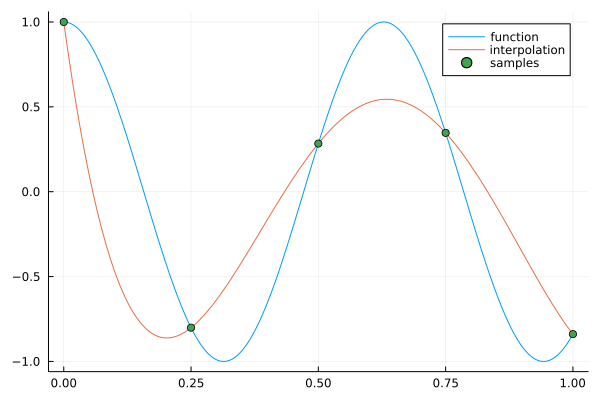

In [2]:
f = x -> cos(10x)
n = 5
𝐱 = range(0, 1; length=n) # evenly spaced points (BAD for interpolation)
V =  [𝐱[j]^k for j = 1:n, k = 0:n-1] # Vandermonde matrix, also can be written as x .^ (0:n)'
𝐟 = f.(𝐱) # evaluate f at x[k], equivalent to [f(x[k]) for k = 1:n]
𝐜 = V \ 𝐟 # invert the Vandermonde matrix and determine the coefficients
p = x -> dot(𝐜, x .^ (0:n-1)) # take a dot product with monomials x .^ 0:n-1 == [x^j for j=0:n-1]
@test p.(𝐱) ≈ V * 𝐜 # evaluating the polynomial on x is the same as applying V


𝐠 = range(0,1; length=1000) # plotting grid, sample a lot more than interpolation points

# To evaluate a polynomial on the plotting grid its faster to create the rectangular Vandermonde matrix associated with that grid:
V_g = [𝐠[j]^k for j = 1:length(𝐠), k = 0:n-1]

plot(𝐠, f.(𝐠); label="function")
plot!(𝐠, V_g*𝐜; label="interpolation")
scatter!(𝐱, f.(𝐱); label="samples")

Whether an interpolation is actually close to a function is a subtle question,
involving properties of the function, distribution of the sample points $x_1,…,x_n$,
and round-off error.
A classic example is:
$$
  f_M(x) = {1 \over M x^2 + 1}
$$
where the choice of $M$ can dictate whether interpolation at evenly spaced points converges.

-------

**Problem 1(a)** Interpolate $1/(4x^2+1)$ and $1/(25x^2 + 1)$ at an evenly spaced grid of $n$
points, plotting the solution at a grid of $1000$ points. For $n = 50$ does your interpolation match
the true function?  Does increasing $n$ to 400 improve the accuracy? How about using `BigFloat`?
Hint: make sure to make your `range` be `BigFloat` valued, e.g., `range(big(-1), big(1); length=n)`.

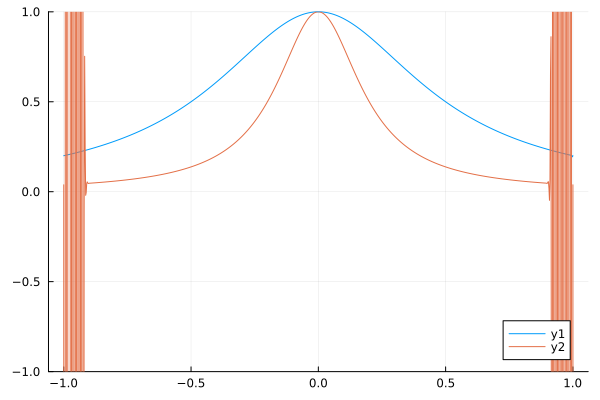

In [3]:
# TODO: interpolate 1/(10x^2 + 1) and 1/(25x^2 + 1) at n evenly spaced points, plotting both solutions evaluated at
# the plotting grid with 1000 points, for n = 50 and 400.

# SOLUTION

n = 50
𝐱 = range(-1, 1; length=n)
𝐠 = range(-1, 1; length=1000) # plotting grid

V = 𝐱 .^ (0:n-1)'
V_g = 𝐠 .^ (0:n-1)'

f_4 = x -> 1/(4x^2 + 1)
𝐜_4 = V \ f_4.(𝐱)
f_25 = x -> 1/(25x^2 + 1)
𝐜_25 = V \ f_25.(𝐱)

plot(𝐠, V_g*𝐜_4; ylims=(-1,1))
plot!(𝐠, V_g*𝐜_25)
# We see large errors near ±1 for both examples.


n = 400
𝐱 = range(-1, 1; length=n)

V = 𝐱 .^ (0:n-1)'
V_g = 𝐠 .^ (0:n-1)'
f_4 = x -> 1/(4x^2 + 1)
𝐜_4 = V \ f_4.(𝐱)
f_25 = x -> 1/(25x^2 + 1)
𝐜_25 = V \ f_25.(𝐱)

plot(𝐠, V_g*𝐜_4; ylims=(-1,1))
plot!(𝐠, V_g*𝐜_25)
#  M = 4 appears to converge whilst M = 25 breaks down.

# Now do big float
n = 400
𝐱 = range(big(-1), 1; length=n)
𝐠 = range(big(-1), 1; length=1000) # plotting grid

V = 𝐱 .^ (0:n-1)'
V_g = 𝐠 .^ (0:n-1)'

f_4 = x -> 1/(4x^2 + 1)
𝐜_4 = V \ f_4.(𝐱)
f_25 = x -> 1/(25x^2 + 1)
𝐜_25 = V \ f_25.(𝐱)

plot(𝐠, V_g*𝐜_4; ylims=(-1,1))
plot!(𝐠, V_g*𝐜_25)
# With M = 4 it looks like it now is converging. This suggests the issue before was numerical error.
# For M = 25 the solution is even less accurate, which suggests the issue is a lack of mathematical
# convergence.

# END

**Problem 1(b)** Repeat the previous problem with the points $x_j = \cos θ_j$ where $θ_j$ are $n$ evenly spaced points
between $0$ and $π$. How do the results compare with evenly spaced points? Do you believe interpolation is now converging?

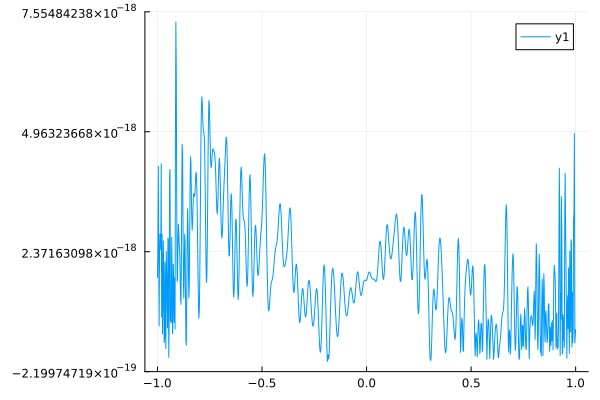

┌ Warning: No strict ticks found
└ @ PlotUtils /Users/solver/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/solver/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/solver/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/solver/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/solver/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/solver/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/solver/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [4]:
# TODO: interpolate 1/(10x^2 + 1) and 1/(25x^2 + 1) at n points given by x_j, plotting both solutions evaluated at
# the plotting grid with 1000 points, for n = 50 and 400.  Does the accuracy improve with BigFloat?

# SOLUTION

n = 50
𝐱 = cos.(range(0,π,n))
𝐠 = range(-1, 1; length=1000) # plotting grid

V = 𝐱 .^ (0:n-1)'
V_g = 𝐠 .^ (0:n-1)'

f_4 = x -> 1/(4x^2 + 1)
𝐜_4 = V \ f_4.(𝐱)
f_25 = x -> 1/(25x^2 + 1)
𝐜_25 = V \ f_25.(𝐱)

plot(𝐠, V_g*𝐜_4; ylims=(-1,1))
plot!(𝐠, V_g*𝐜_25)
# We no longer see large errors.

n = 400
𝐱 = cos.(range(0,π,n))

V = 𝐱 .^ (0:n-1)'
V_g = 𝐠 .^ (0:n-1)'
f_4 = x -> 1/(4x^2 + 1)
𝐜_4 = V \ f_4.(𝐱)
f_25 = x -> 1/(25x^2 + 1)
𝐜_25 = V \ f_25.(𝐱)

plot(𝐠, V_g*𝐜_4; ylims=(-1,1))
plot!(𝐠, V_g*𝐜_25)
# We no longer see large errors in either case.

# we can plot the errors and see they are not that small though
plot(𝐠, abs.(V_g*𝐜_25 - f_25.(𝐠)))

# Now do big float
n = 400
𝐱 = cos.(range(0,big(π),n))
𝐠 = range(big(-1), 1; length=1000) # plotting grid

V = 𝐱 .^ (0:n-1)'
V_g = 𝐠 .^ (0:n-1)'

f_4 = x -> 1/(4x^2 + 1)
𝐜_4 = V \ f_4.(𝐱)
f_25 = x -> 1/(25x^2 + 1)
𝐜_25 = V \ f_25.(𝐱)

# we can plot the errors and see they are really small
plot(𝐠, abs.(V_g*𝐜_25 - f_25.(𝐠)))

In [5]:
# The conclusion is that interpolation converges with this set of points.
# Note we still need BigFloat to see this as the monomial basis is problematic.
# Using orthogonal polynomials (dicussed later) will perform much better.

# END

### IV.1.2 Interpolatory quadrature rules

An interpolatory quadrature rule consists of interpolating samples of a function and integrating
the polynomial exactly. In the notes we constructed such rules by integrating the Lagrange basis,
however, we can also compute the interpolatory polynomial by inverting the Vandermonde matrix.
Here we explore this construction.

**Problem 2(a)** Complete the following function that computes an interpolatory quadrature
$$
\int_0^1 f(x) {\rm d}x ≈ \int_0^1 p(x) {\rm d}x
$$
where $p(x)$ interpolates the data $𝐟 = [f_1,…,f_n]$ (given as a vector) at the given points $𝐱 = [x_1,…,x_n]$ (given as a vector).
Hint: it is much easier to solve a linear system involving the Vandermonde matrix than to use a Lagrange basis.

In [6]:
function interpolatoryquadrature(f::AbstractVector, x::AbstractVector)
    if length(f) ≠ length(x)
        error("lengths must match")
    end
    # TODO: Compute the coefficients of the interpolatory polynomial and integrate it exactly.
    # SOLUTION
        n = length(f)
        V = x .^ (0:n-1)'
        c = V \ f
        ret = 0
        # There are simpler ways to write the following but for clearness lets just do a for-loop:
        for k = 1:n
            ret += c[k]/k # use the fact that ∫_0^1 x^k dx = 1/(k+1)
        end
        ret
    # END
end

x = range(0, 1, 10)
@test interpolatoryquadrature(exp.(x), x) ≈ exp(1)-1

Test Passed

**Problem 2(b)**  Plot the error for the number of evenly spaced points $n = 2, 3, …, 100$ for approximating the integrals
$$
∫_0^1 \exp x {\rm d}x  = ℯ - 1, ∫_0^1 {{\rm d} x \over 25x^2 + 1} = {\rm arctan}(5)/5.
$$
How does the convergence behaviour compare with the Trapezium rule? Does the approximation appear to be stable?
Does using `BigFloat` improve the results? (Hint: `range(0,big(1),n)` will make a sequence of `BigFloat` points.)

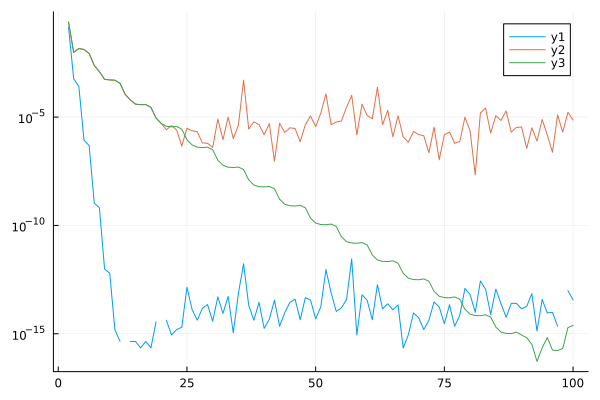

In [7]:
nanabs(x) = x == 0 ? NaN : abs(x)
# TODO: plot the errors for 2,…,100 evenly spaced points for approximating the integral of exp(x) and 1/(25x^2+1)
# SOLUTION
using Plots
ns = 2:100
errs = [(x = range(0,1,n); nanabs(interpolatoryquadrature(exp.(x), x) - (exp(1)-1))) for n=ns]
plot(ns, errs;yscale=:log10) # error appears exponential (actually it's faster than exponential!)
errs = [(x = range(0,1,n); nanabs(interpolatoryquadrature(1 ./ (25x.^2 .+ 1), x) - atan(5)/5)) for n=ns]
plot!(ns, errs;yscale=:log10) # error appears to decay exponentially but then gets stuck 😢 But does better than interpolation
errs = [(x = range(0,big(1),n); nanabs(interpolatoryquadrature(1 ./ (25x.^2 .+ 1), x) - atan(big(5))/5)) for n=ns]
plot!(ns, errs;yscale=:log10) # using BigFloat does better
# END

**Problem 2(c)** Repeat the previous problem with the points $x_j = (\cos θ_j + 1)/2$ where $θ_j$ are $n$ evenly spaced points
between $0$ and $π$. How do the results compare with evenly spaced points?

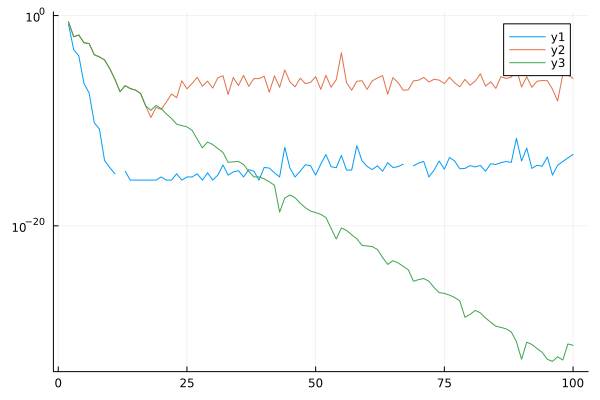

In [8]:
# TODO: plot the errors for 2,…,100 points that are cosines of evenly spaced points, shifted/scaled to be between 0 and 1.
# SOLUTION
errs = [(x = (cos.(range(0,big(π),n)) .+ 1)/2; nanabs(interpolatoryquadrature(1 ./ (25x.^2 .+ 1), x) - atan(5)/5)) for n=ns]
ns = 2:100
errs = [(x = (cos.(range(0,π,n)) .+ 1)/2; nanabs(interpolatoryquadrature(exp.(x), x) - (exp(1)-1))) for n=ns]
plot(ns, errs;yscale=:log10) # error still appears exponential at roughly the same rate as evenly spaced point
errs = [(x =  (cos.(range(0,π,n)) .+ 1)/2; nanabs(interpolatoryquadrature(1 ./ (25x.^2 .+ 1), x) - atan(5)/5)) for n=ns]
plot!(ns, errs;yscale=:log10) # errorstill  appears to decay exponentially but then gets stuck 😢
errs = [(x =  (cos.(range(0,big(π),n)) .+ 1)/2; nanabs(interpolatoryquadrature(1 ./ (25x.^2 .+ 1), x) - atan(big(5))/5)) for n=ns]
plot!(ns, errs;yscale=:log10) # using BigFloat does better. This choice of points converges much faster.

# END

**Problem 3** Typically it's more convenient to compute the quadrature weights $w_j$ so that
$$
\int_0^1 f(x) {\rm d}x ≈ \int_0^1 p(x) {\rm d}x = ∑_{j=1}^n w_j f(x_j).
$$
Compute these weights by solving a linear system involving the transpose of the Vandermonde  matrix.

In [9]:
function interpolatoryweights(x::AbstractVector)
    # TODO: Construct the interpolatory quadrature weights as a vector by solving a linear system involving V'
    # SOLUTION
    # The Vandermonde matrix gives the map to coefficients. We just need to multiply by a row vector
    # corresponding to integrating the monomials exactly. That is, multiplying a vector by
    # [1 1/2 … 1/n] * inv(V)
    # gives the weights as a row vector. But we want a column vector here so we transpose this.
    # Here's a very brief version, but feel free to translate this to a comprehension or for-loop:
    n = length(x)
    V = x .^ (0:n-1)'
    V' \ (1 ./ (1:n))
    # END
end

# We test on the example from the notes:
@test interpolatoryweights([0,1/4,1]) ≈ [-1/6, 8/9, 5/18]

Test Passed

------

### IV.1.3 Polynomial regression

To overcome issues with interpolation we will instead use regression: use more points than
the degree of the polynomial. As an example, suppose we want to fit noisy data by a quadratic
$$
p(x) = c₀ + c₁ x + c₂ x^2.
$$
That is, we want to choose $c₀,c₁,c₂$ at data samples $x_1, …, x_m$ so that the following is true:
$$
c₀ + c₁ x_j + c₂ x_j^2 ≈ f_j
$$
where $f_j$ are given by data. We can reinterpret this as a least squares problem: minimise the norm
$$
\left\| \begin{bmatrix} 1 & x_1 & x_1^2 \\ ⋮ & ⋮ & ⋮ \\ 1 & x_m & x_m^2 \end{bmatrix}
\begin{bmatrix} p₀ \\ p₁ \\ p₂ \end{bmatrix} - \begin{bmatrix} f_1 \\ ⋮ \\ f_m \end{bmatrix} \right \|
$$
When a matrix is rectangular `\` solves a least squares problem for us:

In [10]:
m,n = 100,3

𝐱 = range(0,1; length=m) # 100 points
𝐟 = 2 .+ 𝐱 .+ 2𝐱.^2 .+ 0.1 .* randn.() # Noisy quadratic samples, built with broadcast notation.

V = 𝐱 .^ (0:2)'  # 100 x 3 Vandermonde matrix, equivalent to [ones(m) x x.^2]

𝐜 = V \ 𝐟 # coefficients are, very roughly, [2,1,2]

3-element Vector{Float64}:
 2.0121272348759853
 0.8465612658306291
 2.1670143448288597

We can visualise the fit:

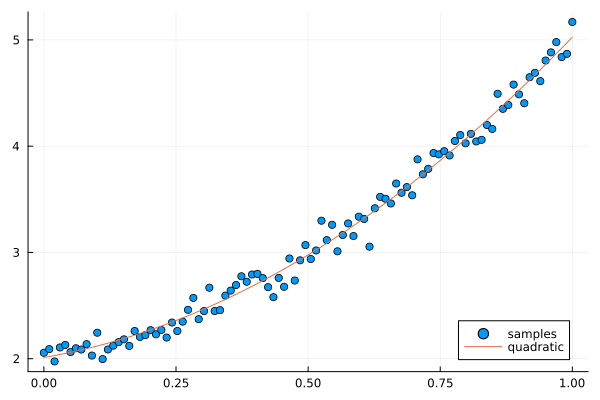

In [11]:
𝐠 =range(0, 1; length=1000)

p = x -> 𝐜[1] + 𝐜[2]x + 𝐜[3]x^2

scatter(𝐱, 𝐟; label="samples", legend=:bottomright)
plot!(𝐠, p.(𝐠); label="quadratic")

-----

**Problem 4** Repeat  Problem 1 but now using _least squares_: instead of interpolating,
use least squares on a large grid: choose the coefficients of a degree $(n-1)$ polynomial so that
$$
    \left\| \begin{bmatrix} p(x_1) \\ ⋮ \\ p(x_m) \end{bmatrix} - \begin{bmatrix} f(x_1) \\ ⋮ \\ f(x_m) \end{bmatrix} \right \|.
$$
is minimised, where $n = 50$ and $m = 500$.
Does this improve the accuracy near the endpoints? Do you think convergence for a least squares approximation
is dictated by the radius of convergence of the corresponding Taylor series?
Hint: use the rectangular Vandermonde matrix to setup the Least squares system. The solution will look extremely similar to Problem 1.

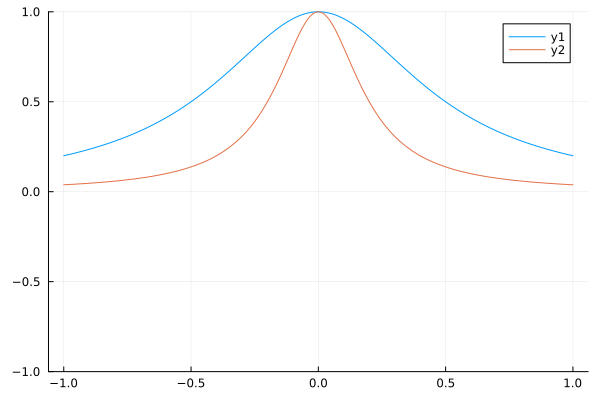

In [12]:
# TODO: approximate 1/(10x^2 + 1) and 1/(25x^2 + 1) using a least squares system.

# SOLUTION
n = 50 # use basis [1,x,…,x^(49)]
𝐱 = range(-1, 1; length=500) # least squares grid
𝐠 = range(-1, 1; length=2000) # plotting grid

V = 𝐱 .^ (0:n-1)'
V_g = 𝐠 .^ (0:n-1)'
f_4 = x -> 1/(4x^2 + 1)
𝐜_4 = V \ f_4.(𝐱)
f_25 = x -> 1/(25x^2 + 1)
𝐜_25 = V \ f_25.(𝐱)

plot(𝐠, V_g*𝐜_4; ylims=(-1,1))
plot!(𝐠, V_g*𝐜_25)

# Yes, now both approximations appear to be converging.
# This is despite the radius of convergence of both functions being
# smaller than the interval of interpolation.

# END

## IV.2 Singular Value Decomposition and Matrix Compression

We now explore using the SVD to compress 2D functions sampled at an
evenly spaced grid. This is very much the same as image compression,
but we will see that samples of smooth functions can be approximated by very small rank matrices.
This gives some intuition on why pictures tend to be low rank: most pictures have large portions that are "smooth".

Note in Julia `opnorm(A)` is the induced matrix 2-norm. `norm(A) == norm(vec(A))` is the Fröbenius norm.

The following code samples a function on a grid in the square `[-1,1]^2`
and plots the corresponding pixels:

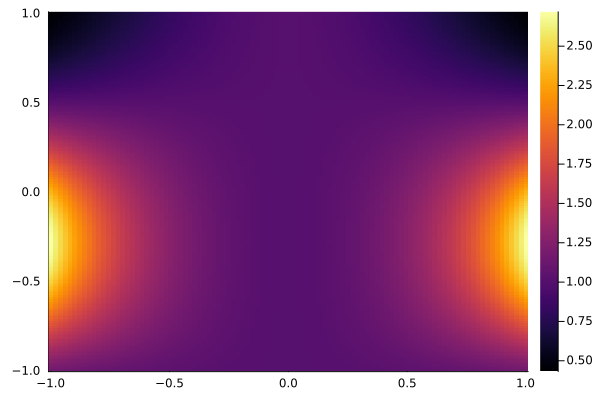

In [13]:
f = (x,y) -> exp(-x^2*sin(2y-1))

m,n = 150,100
x = range(-1, 1; length=n)
y = range(-1, 1; length=m)

F = f.(x', y) # equivalent to [f(x[j],y[k]) for k=1:m, j=1:n]

heatmap(x, y, F)

-----

**Problem 5** Complete the following function `fsample(f, m, n)` which takes in a function
and returns its samples on a grid.

In [14]:
function fsample(f::Function, m::Int, n::Int)
    # TODO: return `f` sampled at an evenly spaced grid on the square [-1, 1]^2
    # with n points in the x direction and
    # n points in the y direction, returning an m × n matrix
    # SOLUTION
    x = range(-1, 1; length=n)
    y = range(-1, 1; length=m)
    f.(x', y)
    # END
end

@test fsample(f, m, n) == F

Test Passed

------
## Singular values of 2D function samples

We will  see experimentally that the singular values
tell us something about the structure functions.  Recall from lectures
the singular value decomposition is a matrix factorization of a
matrix $A ∈ ℝ^{m × n}$ of the form

$$
A = U Σ V^⊤
$$

where $U ∈ ℝ^{m × r}$, $Σ ∈ ℝ^{r × r}$ and $V ∈ ℝ^{n × r}$, where $U$ and $V$
have orthonormal columns and $Σ$ is diagonal.   The singular values are the diagonal entries of $Σ$.

Note that `svdvals(A)` calculates the singular values of a matrix `A`, without calculating
the `U` and `V` components.

-----

**Problem 6(a)** Use `plot(...; yscale=:log10)` and `svdvals` to plot the singular values of
$f(x,y) = \exp(-x^2 \sin(2y-1))$ sampled at a $100 × 150$ evenly spaced grid on $[-1,1]^2$.
At what value does it appear to level off?

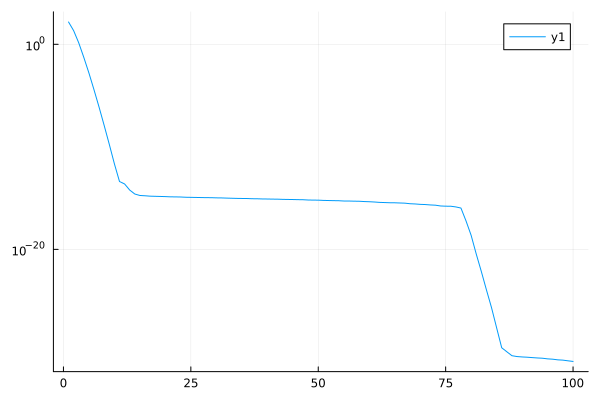

In [15]:
# TODO: Plot the singular values of samples of a smooth function and observe their decay.
# SOLUTION
F = fsample((x,y)->exp(-x^2*sin(2y-1)), 100, 150)
plot(svdvals(F); yscale=:log10)
## It levels off at around 1E-15, close to machine precision. Suprprisingly the last
# few singular values decrease further.
# END

**Problem 6(b)** Repeat Problem 6(a), but plotting the first 20 singular values divided by `n`
for `n = m = 50`, `n = m = 100`, and `n = m = 200` on the same figure, where the function is sampled at
an $n × m$ evenly spaced grid.  What do you notice?
Hint: recall `plot!` adds a plot to an existing plot.

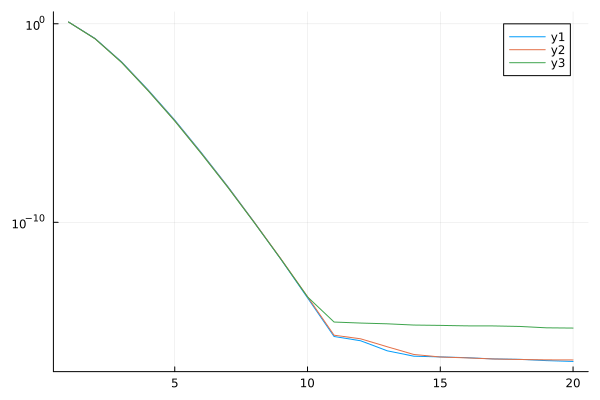

In [16]:
# TODO: Plot the singular values for increasing grid sizes and observe how they remain largely unchanged
# SOLUTION
f = (x,y)->exp(-x^2*sin(2y-1))
plot(svdvals(fsample(f, 50, 50))[1:20]/50; yscale=:log10)
plot!(svdvals(fsample(f, 100, 100))[1:20]/100; yscale=:log10)
plot!(svdvals(fsample(f, 200, 200))[1:20]/200; yscale=:log10)

# we appear to be converging to a fixed distribution
# END

**Problem 6(c)** Plot the first 50 singular values for `n = m = 200` of
 $\cos(ωxy)$ and $\cos(ωx) \cos(ωy)$ for `ω` equal to 1,10 and 50, on the same figure.
How do the singular values change as the functions become more oscillatory in both examples?

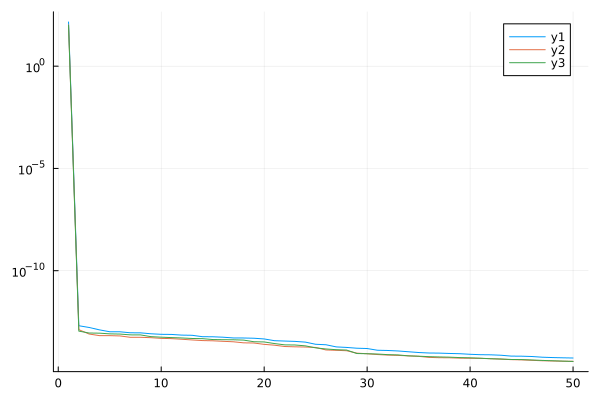

In [17]:
# TODO: See how oscillatory behaviour impacts the rank of the samples.
# SOLUTION
f = (x,y) -> cos(ω*x*y)
g = (x,y) -> cos(ω*x)cos(ω*y)
ω  = 1; plot(svdvals(fsample(f, 200, 200))[1:50]; yscale=:log10)
ω  = 10; plot!(svdvals(fsample(f, 200, 200))[1:50]; yscale=:log10)
ω  = 50; plot!(svdvals(fsample(f, 200, 200))[1:50]; yscale=:log10)

# the singular values plateau for longer when the function becomes oscillatory.

ω  = 1; plot(svdvals(fsample(g, 200, 200))[1:50]; yscale=:log10)
ω  = 10; plot!(svdvals(fsample(g, 200, 200))[1:50]; yscale=:log10)
ω  = 50; plot!(svdvals(fsample(g, 200, 200))[1:50]; yscale=:log10)

# this is a rank-1 function so the singular values are independent of ω.

# END

**Problem 6(d)** Plot the singular values of ${\rm sign}(x-y)$ for `n=m=100`
and `n=m=200`.  What do you notice?

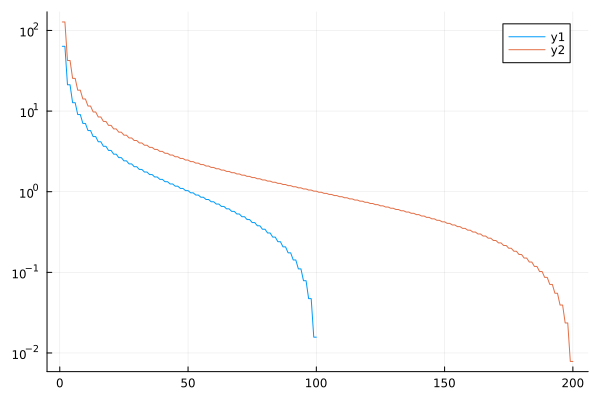

In [18]:
# TODO: See how a diagonal jump impacts the rank of the samples.
# SOLUTION
f = (x,y) -> sign(x-y)
plot(svdvals(fsample(f, 100, 100)); yscale=:log10)
plot!(svdvals(fsample(f, 200, 200)); yscale=:log10)
# They don't decay. Loss of smoothness means we no longer have a rapid decrease in singular values.
# END

-----
## Matrix compression

We now turn to using the SVD to compress matrices. In particular, the following problems explore how we can use
the approximation
$$
A ≈ A_k := \underbrace{\begin{bmatrix} 𝐮_1 | ⋯ | 𝐮_k \end{bmatrix}}_{=: U_k ∈ ℝ^{m × k}} \underbrace{\begin{bmatrix}
σ_1 \\
& ⋱ \\
&& σ_k\end{bmatrix}}_{=: Σ_k ∈ ℝ^{k × k}} \underbrace{\begin{bmatrix} 𝐯_1 | ⋯ | 𝐯_k \end{bmatrix}^⊤}_{=: V_k^⊤ ∈ ℝ^{k × n}}
$$
to approximate a matrix (say, coming from function samples, or pixels of image, or even weights in a Neural Network)
using significantly less data.

-----

**Problem 7(a)** Write a function `svdcompress(A::Matrix, k::Integer)` that returns the best rank-`k` approximation to `A`,
using the in-built `svd` command.

In [19]:
function svdcompress(A::Matrix, k::Integer)
    # TODO: Implement the best rank-k approximation
    # SOLUTION
    U,σ,V = svd(A)
    U[:,1:k] * Diagonal(σ[1:k]) * V[:,1:k]'
    # END
end

svdcompress (generic function with 1 method)

**Problem 7(b)** Compare a `heatmap` plot of `fsample((x,y) -> exp(-x^2*sin(2y-1)), 100, 100)` to its best rank-5 approximation.
What do you observe?

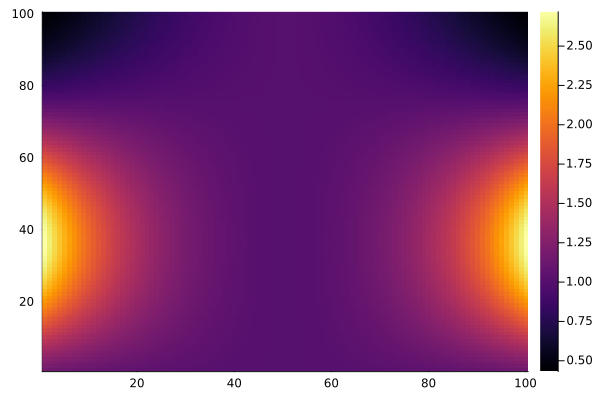

In [20]:
# TODO: compare a simple function with its low rank approximation.
# SOLUTION
F = fsample((x,y) -> exp(-x^2*sin(2y-1)), 100, 100)
heatmap(F)

F_c = svdcompress(F, 5)
heatmap(F_c)

# There is no obvious difference
# END

**Problem 7(c)** Write a function `svdcompress_rank(A::Matrix, ε::Real)` that returns the smallest integer `k` so that `opnorm(A - svdcompress(A, k)) ≤ ε`,
which we call the "numerical rank".   (Hint: use the singular values instead of guess-and-check.)

In [21]:
function svdcompress_rank(A::Matrix, ε::Real)
    # TODO: determine and return rank-k approximation
    # SOLUTION
    σ = svdvals(A)
    for k = 1:length(σ)
        if σ[k] ≤ ε
            return k-1
        end
    end
    return length(σ)
    # END
end
F = fsample((x,y) -> exp(-x^2*sin(2y-1)), 100, 100)
@test svdcompress_rank(F, 1E-10) == 9

Test Passed

**Problem 7(d)** Use `svdcompress_rank` to roughly estimate how the numerical rank of the Hilbert matrix
$$
H_n := \begin{bmatrix} 1 & 1/2 & 1/3 & ⋯ & 1/n \\
                      1/2 & 1/3 & 1/4 & ⋯ & 1/(n+1) \\
                       1/3 & 1/4 & 1/5 & ⋯ & 1/(n+2) \\
                       ⋮ & ⋮ & ⋮ & ⋱ & ⋮ \\
                       1/n & 1/(n+1) & 1/(n+2) & ⋯ & 1/(2n-1)
                       \end{bmatrix}
$$
grows as a function
of $n$ up to $n = 200$, for $ε = 10^{-10}$.
Hint: scaling just the x axis in a plot via `plot(...; xscale=:log10)` will reveal logarithmic
growth.

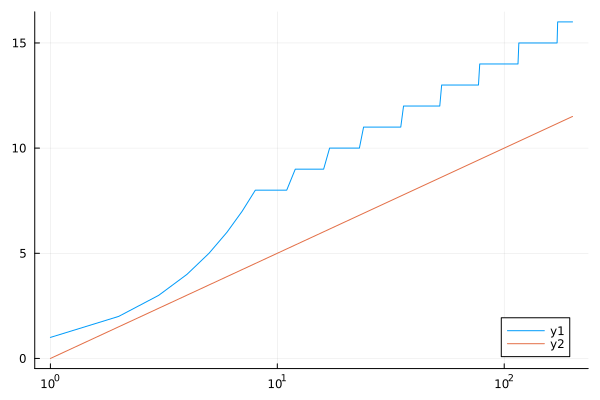

In [22]:
# TODO: investigate the rank structure of the Hilbert matrix
# SOLUTION

hilbertmatrix(n) = [1/(k + j - 1) for k=1:n, j=1:n]

plot([svdcompress_rank(hilbertmatrix(n), 1E-10) for n=1:200], xscale=:log10)
plot!(5log10.((1:200)))

# We see it grows roughly like $5log(n)$.


# END

-----

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*